# Output-digit-balanced carry localisation

This is one final, predeclared test of whether the selected mathematics TopK-256 SAE contains a compact carry-associated panel that the single-prompt attribution graph missed. It does **not** retrain the model or SAE.

The experiment uses all 57,344 latents across layers 4, 8, 12, 16, 20, 24 and 28. Features are ranked only on discovery prompts by their carry-versus-no-carry activation difference **within groups that predict the same tens digit**. The Top-10 order is then frozen and tested on disjoint matched carry/no-carry pairs using final-token, error-preserving inhibition. A raw-MLP conditional direction is evaluated in parallel to distinguish an SAE-basis failure from a weak final-token MLP site.

The joint primary criterion is fixed before the run: the Top-10 panel must retain a positive output-digit-conditioned activation effect on confirmation data, reduce the carry-target gap, and have a carry-minus-control causal bootstrap interval wholly below zero. Secondary panel sizes and random controls must not be used to replace the primary result.

## 1. Mount Drive and fetch the current repository

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import subprocess

repo_url = 'https://github.com/evey-dev/test_run.git'
repo_dir = '/content/test_run'

def run_cmd(command):
    print('$', ' '.join(map(str, command)), flush=True)
    env = os.environ.copy()
    env['PYTHONUNBUFFERED'] = '1'
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )
    for line in process.stdout:
        print(line, end='', flush=True)
    return_code = process.wait()
    if return_code:
        raise subprocess.CalledProcessError(return_code, command)

github_ok = False
try:
    checkout = repo_dir
    if os.path.isdir(os.path.join(checkout, '.git')):
        run_cmd(['git', '-C', checkout, 'pull', '--ff-only'])
    else:
        if os.path.exists(checkout) and os.listdir(checkout):
            checkout = '/content/test_run_github'
        if os.path.isdir(os.path.join(checkout, '.git')):
            run_cmd(['git', '-C', checkout, 'pull', '--ff-only'])
        elif os.path.exists(checkout) and os.listdir(checkout):
            raise RuntimeError(f'{checkout} exists but is not a git repository')
        else:
            run_cmd(['git', 'clone', '--depth', '1', repo_url, checkout])
    os.chdir(checkout)
    github_ok = True
    print('Using GitHub checkout:', os.getcwd())
except Exception as exc:
    print('GitHub checkout failed; using Drive project.zip backup.')
    print(repr(exc))

if not github_ok:
    zip_path = '/content/drive/MyDrive/mphil-project/project.zip'
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f'Could not find {zip_path}')
    run_cmd(['unzip', '-q', '-o', zip_path, '-d', '/content/'])
    for candidate in ['/content/test_run', '/content/mphil_project/test_run', '/content']:
        if os.path.isdir(os.path.join(candidate, 'src')) and os.path.isdir(os.path.join(candidate, 'configs')):
            os.chdir(candidate)
            break
    else:
        raise FileNotFoundError('Could not locate the extracted repository root')

print('Current working directory:', os.getcwd())

Mounted at /content/drive
$ git -C /content/test_run pull --ff-only
Using GitHub checkout: /content/test_run
Current working directory: /content/test_run


## 2. Install dependencies and restore the selected SAE

In [2]:
# Keep Colab's mutually compatible Matplotlib and pandas builds. Upgrading them
# in a live kernel can mix already-imported modules with newly installed files.
!pip install -q --upgrade "transformers>=4.51.0" accelerate
!pip install -q -e .
!python data/generate_datasets.py --capitals

from pathlib import Path
required_files = [
    Path('src/math_carry_balanced_localization.py'),
    Path('src/math_carry_top20_replication.py'),
    Path('configs/sae_math_topk256_config.yaml'),
]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        'Push the balanced-localisation code to GitHub before running this notebook: ' +
        ', '.join(missing_files)
    )

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 150.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 154.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 128.9 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
  Preparing metadata (setup.py) ... done
Generating Datasets...

Flag '--capitals' captured. Building structural se

In [3]:
import json
import shutil
import sys

LAYERS = [4, 8, 12, 16, 20, 24, 28]
DRIVE_ROOT = Path('/content/drive/MyDrive/mphil-project')
DRIVE_CHECKPOINT = DRIVE_ROOT / 'mechanistic_data' / 'topk_math_retrain' / 'k256'
DRIVE_RETRAIN_OUTPUT = DRIVE_ROOT / 'outputs' / 'topk_math_retrain'
DRIVE_FOLLOWUP_OUTPUT = DRIVE_ROOT / 'outputs' / 'topk_math_followup'
DRIVE_OUTPUT = DRIVE_ROOT / 'outputs' / 'math_carry_localization'
LOCAL_CHECKPOINT = Path('mechanistic_data/sae_checkpoints_math_topk256')
LOCAL_OUTPUT = Path('outputs/math_carry_localization')

for path in (DRIVE_OUTPUT, LOCAL_CHECKPOINT, LOCAL_OUTPUT):
    path.mkdir(parents=True, exist_ok=True)

for layer in LAYERS:
    for name in (f'sae_layer{layer}.pt', f'sae_layer{layer}_metadata.json'):
        source = DRIVE_CHECKPOINT / name
        destination = LOCAL_CHECKPOINT / name
        if not source.exists():
            raise FileNotFoundError(f'Missing selected TopK checkpoint artifact: {source}')
        if not destination.exists():
            shutil.copy2(source, destination)
            print('Restored', destination)

PRIOR_RESULTS = [
    DRIVE_RETRAIN_OUTPUT / 'math_topk256_heldout_specificity.json',
    DRIVE_FOLLOWUP_OUTPUT / 'math_topk256_carry_feature_screen.json',
]
missing_prior = [str(path) for path in PRIOR_RESULTS if not path.exists()]
if missing_prior:
    raise FileNotFoundError(
        'The prior result files are required so their cases can be excluded: ' +
        ', '.join(missing_prior)
    )

RESULT_PATH = DRIVE_OUTPUT / 'math_topk256_balanced_carry_localization.json'
CACHE_PATH = DRIVE_OUTPUT / 'math_topk256_balanced_carry_activations.npz'
print('Result checkpoint:', RESULT_PATH)
print('Activation cache:', CACHE_PATH)
print('Previously inspected result files:', *PRIOR_RESULTS, sep='\n  ')

Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer4.pt
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer4_metadata.json
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer8.pt
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer8_metadata.json
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer12.pt
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer12_metadata.json
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer16.pt
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer16_metadata.json
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer20.pt
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer20_metadata.json
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer24.pt
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer24_metadata.json
Restored mechanistic_data/sae_checkpoints_math_topk256/sae_layer28.pt
Restored mechanistic_data/sa

## 3. Run the balanced discovery and frozen confirmation

The result JSON is checkpointed to Drive after every causal panel, and the activation matrix is cached after capture. If Colab disconnects, rerun this cell with the same arguments. Do not add `--overwrite` unless intentionally restarting the entire predeclared protocol.

In [4]:
command = [
    sys.executable, '-u', '-m', 'src.math_carry_balanced_localization',
    '--sae-config', 'configs/sae_math_topk256_config.yaml',
    '--candidate-pairs', '149',
    '--discovery-pairs', '32',
    '--confirmation-pairs', '32',
    '--seed', '4787',
    '--batch-size', '4',
    '--panel-sizes', '1', '3', '5', '10', '20',
    '--primary-panel-size', '10',
    '--random-panels', '5',
    '--minimum-active-fraction', '0.10',
    '--minimum-positive-stratum-fraction', '0.60',
    '--exclude-json', *map(str, PRIOR_RESULTS),
    '--output', str(RESULT_PATH),
    '--activation-cache', str(CACHE_PATH),
]
run_cmd(command)

$ /usr/bin/python3 -m src.math_carry_balanced_localization --sae-config configs/sae_math_topk256_config.yaml --candidate-pairs 149 --discovery-pairs 32 --confirmation-pairs 32 --seed 4787 --batch-size 4 --panel-sizes 1 3 5 10 20 --primary-panel-size 10 --random-panels 5 --minimum-active-fraction 0.10 --minimum-positive-stratum-fraction 0.60 --exclude-json /content/drive/MyDrive/mphil-project/outputs/topk_math_retrain/math_topk256_heldout_specificity.json /content/drive/MyDrive/mphil-project/outputs/topk_math_followup/math_topk256_carry_feature_screen.json --output /content/drive/MyDrive/mphil-project/outputs/math_carry_localization/math_topk256_balanced_carry_localization.json --activation-cache /content/drive/MyDrive/mphil-project/outputs/math_carry_localization/math_topk256_balanced_carry_activations.npz


## 4. Inspect the predeclared result

In [5]:
import pandas as pd
from IPython.display import display

result = json.loads(RESULT_PATH.read_text())
print('Status:', result['status'])
print('Excluded previously inspected pairs:', result['exclusions']['excluded_case_count'])
print('Eligible fresh pairs:', result['baseline_screen']['eligible_pairs'])
print('Discovery pairs:', len(result['split']['discovery_case_keys']))
print('Confirmation pairs:', len(result['split']['confirmation_case_keys']))
print('Joint predeclared success:', result['primary_result']['supports_compact_carry_selectivity_under_predeclared_rule'])
print(result['primary_result']['interpretation_gate'])

raw_table = pd.DataFrame([
    {
        'layer': row['layer'],
        'discovery conditioned AUC': row['discovery']['output_digit_conditioned_auc'],
        'confirmation conditioned AUC': row['confirmation']['output_digit_conditioned_auc'],
        'confirmation effect': row['confirmation']['mean_within_digit_carry_minus_no_carry'],
        'confirmation 95% CI': row['confirmation']['bootstrap_95_ci_mean_within_digit_difference'],
    }
    for row in result['raw_mlp_localisation']
]).set_index('layer')
display(raw_table)

ranking_table = pd.DataFrame(result['sae_feature_discovery']['top_200_ranking'][:20])
display(ranking_table[[
    'rank', 'key', 'conditional_standardised_effect',
    'positive_output_digit_strata', 'total_output_digit_strata',
    'carry_active_fraction', 'no_carry_active_fraction',
]])

Status: complete
Excluded previously inspected pairs: 44
Eligible fresh pairs: 105
Discovery pairs: 32
Confirmation pairs: 32
Joint predeclared success: False
The existing final-token MLP SAE basis did not isolate a compact carry-selective panel.


,discovery conditioned AUC,confirmation conditioned AUC,confirmation effect,confirmation 95% CI
layer,,,,
4,0.861548,0.754286,8.320636,"[4.7699273228645325, 11.951610379559654]"
8,0.872024,0.800000,7.333039,"[4.470286998578481, 10.183812619958605]"
12,0.650952,0.474286,0.414013,"[-3.5757231286593845, 4.7693079446043285]"
16,0.636905,0.445714,-2.058077,"[-5.987781589371817, 1.8656304065670266]"
20,0.619286,0.308571,-3.465958,"[-8.216025822503225, 1.1603404900857344]"
24,1.000000,1.000000,26.836422,"[24.539188650676184, 29.14912952014378]"
28,1.000000,1.000000,26.331911,"[24.848478473935806, 27.907149246760778]"


,rank,key,conditional_standardised_effect,positive_output_digit_strata,total_output_digit_strata,carry_active_fraction,no_carry_active_fraction
0,1,L24F579,1.280605,7,7,0.87500,0.50000
1,2,L28F374,1.226962,6,7,0.50000,0.03125
2,3,L28F531,1.226472,7,7,0.53125,0.03125
3,4,L28F7669,1.106004,7,7,0.65625,0.12500
4,5,L28F2205,1.103223,6,7,0.56250,0.15625
5,6,L24F5667,1.101201,7,7,0.59375,0.12500
6,7,L24F2180,1.099107,5,7,0.53125,0.00000
7,8,L28F7718,1.070369,5,7,0.53125,0.09375
8,9,L28F325,1.067612,6,7,0.56250,0.18750
9,10,L24F2273,1.066366,6,7,0.71875,0.31250


In [6]:
panel_table = pd.DataFrame([
    {
        'panel': panel['name'],
        'kind': panel['kind'],
        'features': panel['feature_count'],
        'activation confirmation': panel['activation_validation']['confirmation']['mean_within_digit_carry_minus_no_carry'],
        'activation CI': panel['activation_validation']['confirmation']['bootstrap_95_ci_mean_within_digit_difference'],
        'carry target delta': panel['causal_summary']['mean_carry_target_delta'],
        'no-carry control delta': panel['causal_summary']['mean_no_carry_control_delta'],
        'causal specificity': panel['causal_summary']['mean_paired_difference'],
        'causal 95% CI': panel['causal_summary']['bootstrap_95_ci_mean_paired_difference'],
    }
    for panel in result['causal_confirmation']['panels']
])
display(panel_table)
display(pd.Series(result['primary_result']['activation_confirmation']).to_frame('activation confirmation'))
display(pd.Series(result['primary_result']['causal_confirmation']).to_frame('causal confirmation'))

,panel,kind,features,activation confirmation,activation CI,carry target delta,no-carry control delta,causal specificity,causal 95% CI
0,top_1,balanced_activation_ranked_prefix,1,1.112048,"[0.8392254564378943, 1.3751398227576697]",-0.031250,-0.015625,-0.015625,"[-0.0546875, 0.02734375]"
1,top_3,balanced_activation_ranked_prefix,3,1.292105,"[1.0955350886498179, 1.4750188188893454]",-0.035156,-0.015625,-0.019531,"[-0.06640625, 0.02734375]"
2,top_5,balanced_activation_ranked_prefix,5,1.307229,"[1.1554904199072293, 1.4690065081630435]",-0.050781,-0.035156,-0.015625,"[-0.05078125, 0.0234375]"
3,top_10_primary,balanced_activation_ranked_prefix,10,1.129735,"[1.010573719867638, 1.2530636910881316]",-0.007812,-0.023438,0.015625,"[-0.03515625, 0.0625]"
4,top_20,balanced_activation_ranked_prefix,20,0.967376,"[0.86605347267219, 1.0768110356160572]",-0.078125,0.023438,-0.101562,"[-0.1484375, -0.05078125]"
5,random_matched_01,layer_count_matched_balanced_candidate_control,10,0.483900,"[0.41555139965244703, 0.5554030121437141]",0.011719,-0.031250,0.042969,"[0.0078125, 0.078125]"
6,random_matched_02,layer_count_matched_balanced_candidate_control,10,0.532378,"[0.44258820797715864, 0.6223113646996872]",-0.027344,-0.011719,-0.015625,"[-0.0546875, 0.0234375]"
7,random_matched_03,layer_count_matched_balanced_candidate_control,10,0.462272,"[0.4030510290924992, 0.5236236540334565]",-0.007812,-0.058594,0.050781,"[-0.0078125, 0.109375]"
8,random_matched_04,layer_count_matched_balanced_candidate_control,10,0.439034,"[0.3632281073502132, 0.5149196021258831]",0.000000,-0.035156,0.035156,"[0.0, 0.06640625]"
9,random_matched_05,layer_count_matched_balanced_candidate_control,10,0.603141,"[0.5386006617120335, 0.670167690621955]",-0.023438,-0.015625,-0.007812,"[-0.04296875, 0.02734375]"


,activation confirmation
observation_count,64
common_output_digits,"[1, 2, 3, 4, 5, 6, 7]"
common_output_digit_count,7
mean_within_digit_carry_minus_no_carry,1.129735
bootstrap_95_ci_mean_within_digit_difference,"[1.010573719867638, 1.2530636910881316]"
output_digit_conditioned_auc,1.0
stratum_effects,"{'1': 1.5116850137710571, '2': 0.9267659187316..."


,causal confirmation
eligible_pairs,32
mean_carry_target_delta,-0.007812
bootstrap_95_ci_mean_carry_target_delta,"[-0.046875, 0.03125]"
mean_no_carry_control_delta,-0.023438
bootstrap_95_ci_mean_no_carry_control_delta,"[-0.0546875, 0.0078125]"
mean_paired_difference,0.015625
bootstrap_95_ci_mean_paired_difference,"[-0.03515625, 0.0625]"
fraction_carry_more_negative_than_control,0.3125
fraction_carry_delta_negative,0.3125
carry_top_prediction_transfer_fraction,0.0


## 5. Save a diagnostic figure and local result copy

Matplotlib PDF backend was inconsistent; saved a raster PDF from the PNG instead.


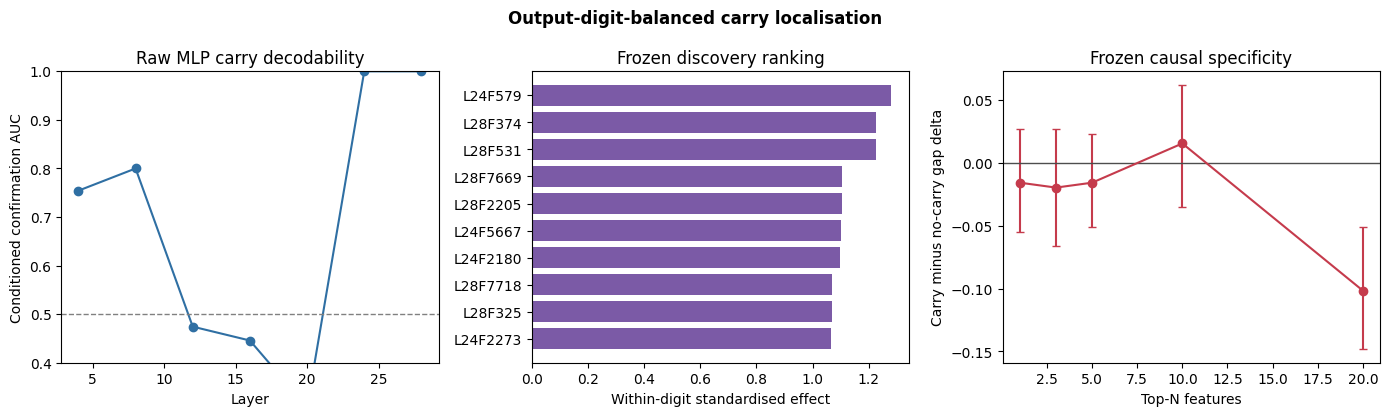

Copied outputs/math_carry_localization/math_topk256_balanced_carry_localization.json
Copied outputs/math_carry_localization/fig_math_balanced_carry_localization.png
Copied outputs/math_carry_localization/fig_math_balanced_carry_localization.pdf


In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

raw_layers = [row['layer'] for row in result['raw_mlp_localisation']]
raw_auc = [row['confirmation']['output_digit_conditioned_auc'] for row in result['raw_mlp_localisation']]
axes[0].plot(raw_layers, raw_auc, marker='o', color='#2F6FA3')
axes[0].axhline(0.5, color='0.5', linestyle='--', linewidth=1)
axes[0].set(title='Raw MLP carry decodability', xlabel='Layer', ylabel='Conditioned confirmation AUC', ylim=(0.4, 1.0))

top = result['sae_feature_discovery']['top_200_ranking'][:10]
axes[1].barh([row['key'] for row in reversed(top)], [row['conditional_standardised_effect'] for row in reversed(top)], color='#7B5AA6')
axes[1].set(title='Frozen discovery ranking', xlabel='Within-digit standardised effect')

ranked_panels = [panel for panel in result['causal_confirmation']['panels'] if panel['kind'] == 'balanced_activation_ranked_prefix']
x = [panel['feature_count'] for panel in ranked_panels]
y = [panel['causal_summary']['mean_paired_difference'] for panel in ranked_panels]
lo = [panel['causal_summary']['bootstrap_95_ci_mean_paired_difference'][0] for panel in ranked_panels]
hi = [panel['causal_summary']['bootstrap_95_ci_mean_paired_difference'][1] for panel in ranked_panels]
axes[2].errorbar(x, y, yerr=[np.asarray(y) - np.asarray(lo), np.asarray(hi) - np.asarray(y)], marker='o', color='#C53B4C', capsize=3)
axes[2].axhline(0, color='0.3', linewidth=1)
axes[2].set(title='Frozen causal specificity', xlabel='Top-N features', ylabel='Carry minus no-carry gap delta')

fig.suptitle('Output-digit-balanced carry localisation', fontweight='bold')
fig.tight_layout()
figure_png = DRIVE_OUTPUT / 'fig_math_balanced_carry_localization.png'
figure_pdf = DRIVE_OUTPUT / 'fig_math_balanced_carry_localization.pdf'
fig.savefig(figure_png, dpi=220, bbox_inches='tight')
try:
    fig.savefig(figure_pdf, bbox_inches='tight')
except ImportError as exc:
    # A live Colab kernel can retain an older font_manager after pip changes,
    # while the deferred PDF backend comes from the new installation. Convert
    # the successfully rendered PNG without importing that backend.
    if 'FontPath' not in str(exc):
        raise
    from PIL import Image as PILImage
    with PILImage.open(figure_png) as rendered:
        rendered.convert('RGB').save(figure_pdf, 'PDF', resolution=220.0)
    print('Matplotlib PDF backend was inconsistent; saved a raster PDF from the PNG instead.')
plt.show()

for source in (RESULT_PATH, figure_png, figure_pdf):
    destination = LOCAL_OUTPUT / source.name
    shutil.copy2(source, destination)
    print('Copied', destination)

## Interpretation gate

- **Raw MLP confirmation AUC near 0.5:** carry is not linearly exposed at this final-token MLP site under output-digit control; another component or position would be a future study.
- **Raw MLP signal but no held-out SAE activation signal:** the existing SAE basis does not align cleanly with the decodable carry direction.
- **Held-out SAE activation signal but failed causal specificity:** carry is decodable from the panel, but the selected features are not established as a selective causal mechanism.
- **Joint primary rule passes:** report a compact carry-selective candidate only after one independent replication with a new seed and untouched cases.
- **Joint primary rule fails:** do not replace it with the secondary Top-20 result. The next section treats Top-20 only as hypothesis generation and permits one independent replication, not another panel search.

## 6. Independent replication of the exploratory Top-20 effect

The original Top-10 primary failed. The prespecified secondary Top-20 panel nevertheless produced a carry-minus-control effect of approximately `-0.102` with its interval below zero. That observation is now treated only as hypothesis generation.

This section reads the exact frozen Top-20 IDs from the completed result and tests that one panel on 32 of the 41 eligible pairs that received baselines but **no feature intervention** in the first run. Cases are chosen using only baseline eligibility and output-digit balance. No features are reranked, no alternative panel is tested, and the replication succeeds only if the carry-target mean is negative and the paired bootstrap interval is wholly below zero.

In [ ]:
REPLICATION_PATH = DRIVE_OUTPUT / 'math_topk256_balanced_top20_replication.json'
replication_command = [
    sys.executable, '-u', '-m', 'src.math_carry_top20_replication',
    '--sae-config', 'configs/sae_math_topk256_config.yaml',
    '--source-result', str(RESULT_PATH),
    '--replication-pairs', '32',
    '--seed', '9787',
    '--selection-trials', '4000',
    '--output', str(REPLICATION_PATH),
]
run_cmd(replication_command)

In [ ]:
replication = json.loads(REPLICATION_PATH.read_text())
replication_primary = replication['primary_result']
replication_summary = replication_primary['causal_summary']
print('Status:', replication['status'])
print('Frozen Top-20 replication passed:', replication_primary['replicates_frozen_top20_carry_selectivity'])
print(replication_primary['interpretation_gate'])
print('Untouched eligible pairs before selection:', replication['case_selection']['intervention_untouched_eligible_pair_count'])
print('Replication pairs:', replication['case_selection']['selected_replication_pair_count'])
display(pd.Series(replication_summary).to_frame('independent replication'))

local_replication = LOCAL_OUTPUT / REPLICATION_PATH.name
shutil.copy2(REPLICATION_PATH, local_replication)
print('Copied', local_replication)

## Final stopping rule

- **Replication passes:** report the first Top-20 result as exploratory discovery and this run as its independent causal replication. The defensible claim is a distributed twenty-feature carry-associated causal panel, not a monosemantic carry bit or a complete addition circuit.
- **Replication fails:** report perfect held-out carry decodability but no replicated sparse causal panel. The secondary Top-20 result was not robust.
- In either case, stop. Do not test another panel size or seed on these remaining cases.